In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Telecom_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df[df["TotalCharges"].isin([" ","NA","-"])==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [5]:
df["TotalCharges"]=df["TotalCharges"].replace(" ",np.nan)

In [6]:
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [7]:
df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)

C:\Users\Ankita Singh\AppData\Local\Temp\ipykernel_16252\3497282575.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)


In [8]:
df.drop("customerID",axis=1,inplace=True)

In [9]:
Numerical=df.select_dtypes(exclude="object")
Categorical=df.select_dtypes(include="object")

In [10]:
for i in Categorical:
    print(i)
    print(df[i].value_counts())
    print("="*100)

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
TechSupport
No                     34

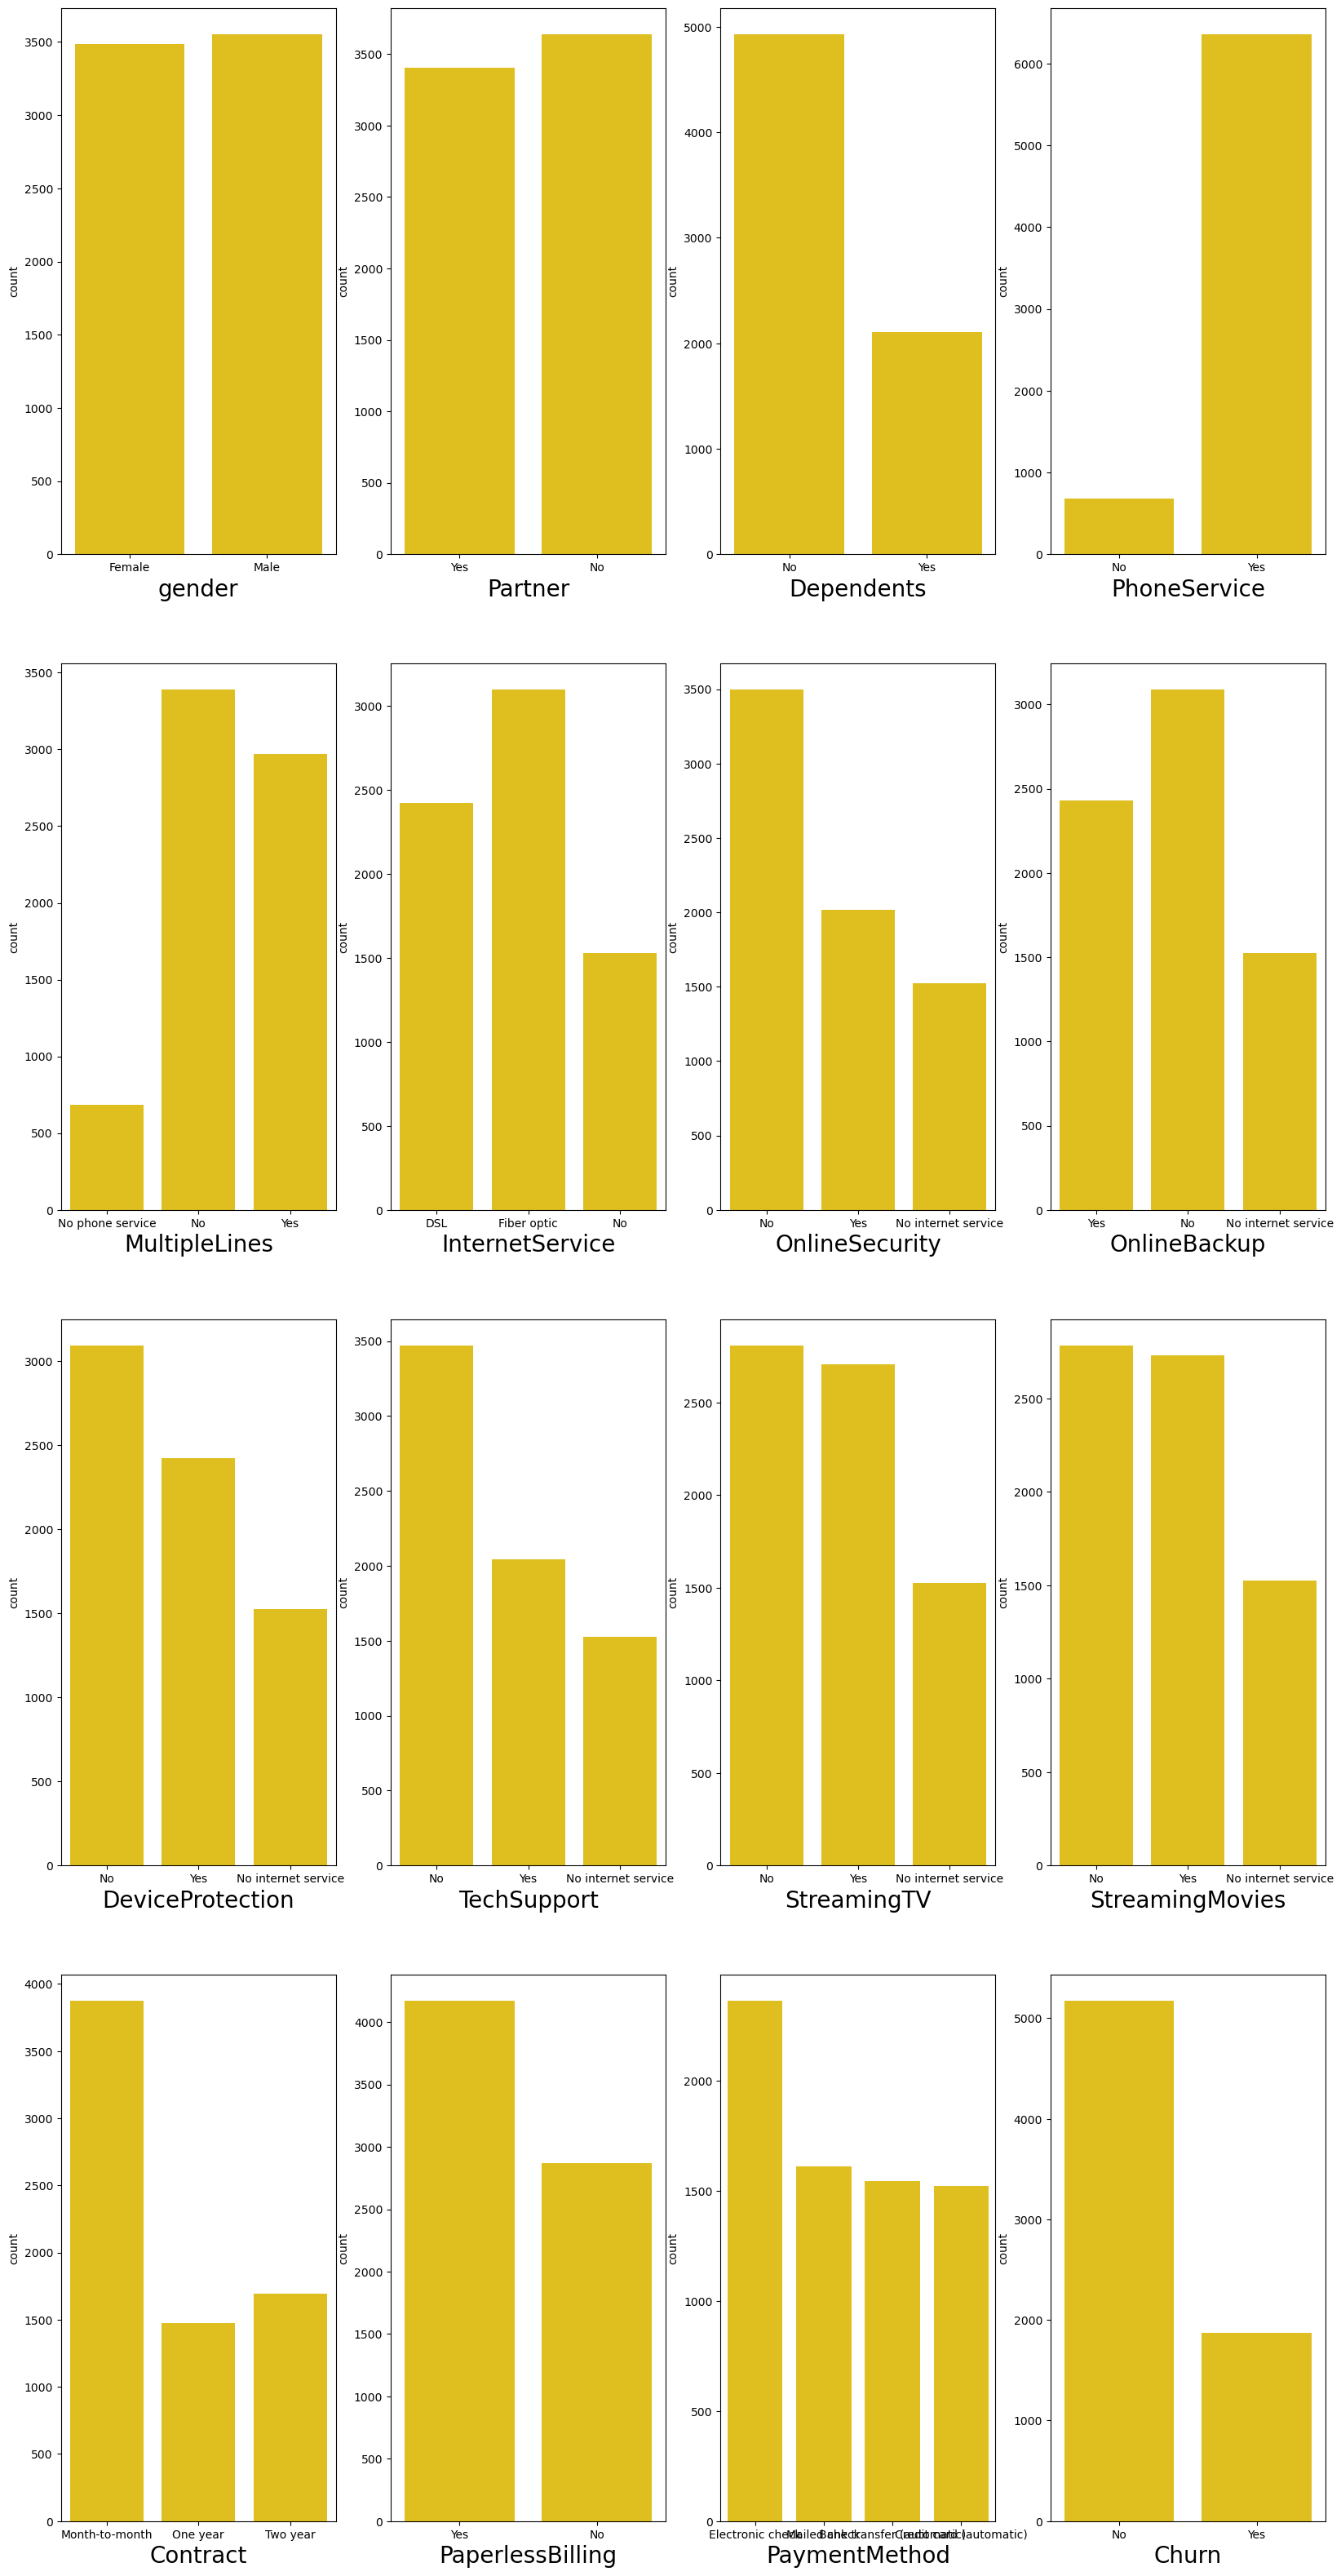

In [11]:
sns.set_palette("hsv")
plt.figure(figsize=(20,40),facecolor="white")
plotnumber=1
for i in Categorical:
    if plotnumber <=16:
        ax=plt.subplot(4,4,plotnumber)
        sns.countplot(x=df[i])
        plt.xlabel(i,fontsize=20)
    plotnumber+=1
plt.show()

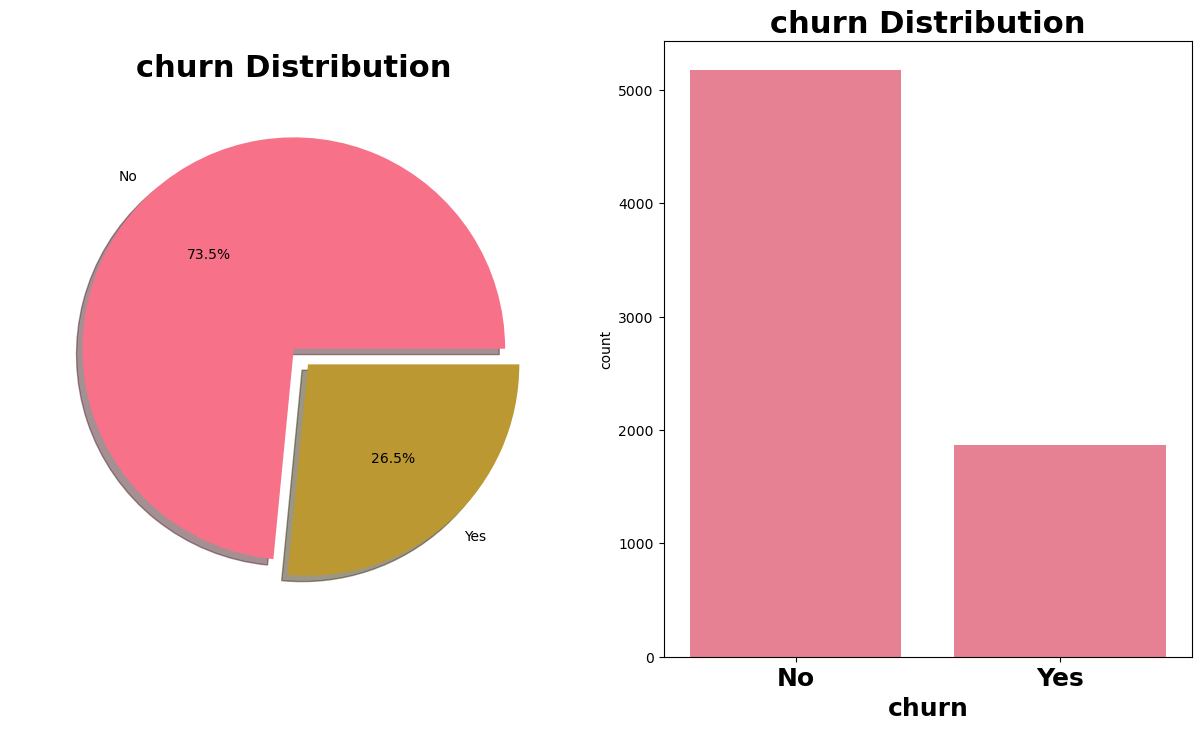

In [12]:
sns.set_palette("husl")
f,ax=plt.subplots(1,2,figsize=(15,8))
df["Churn"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("churn Distribution",fontsize=22,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="Churn",data=df,ax=ax[1])
ax[1].set_title("churn Distribution",fontsize=22,fontweight="bold")
ax[1].set_xlabel("churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.show()

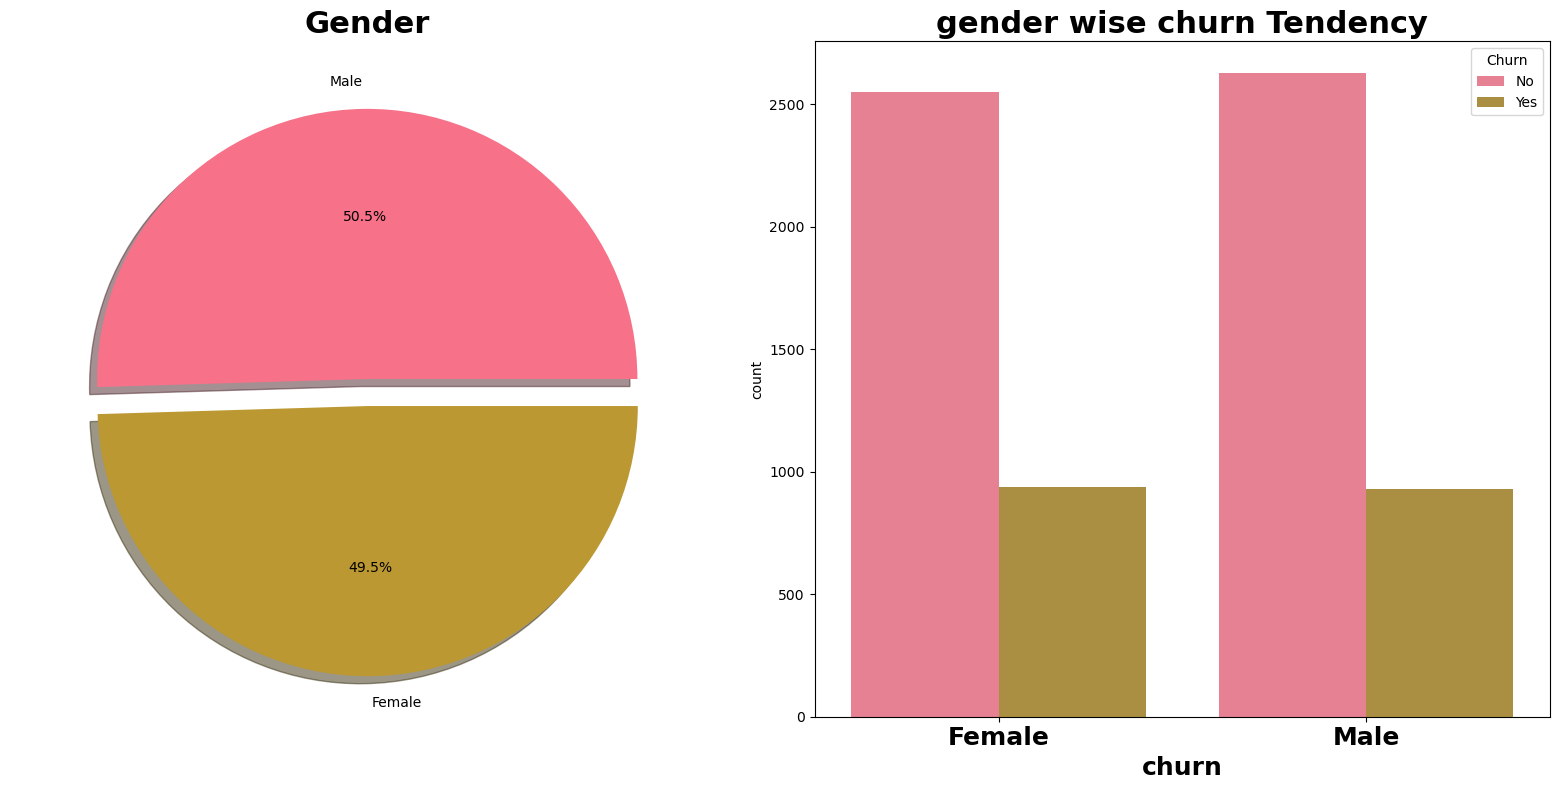

In [13]:
sns.set_palette("husl")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["gender"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("Gender",fontsize=22,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="gender",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("gender wise churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

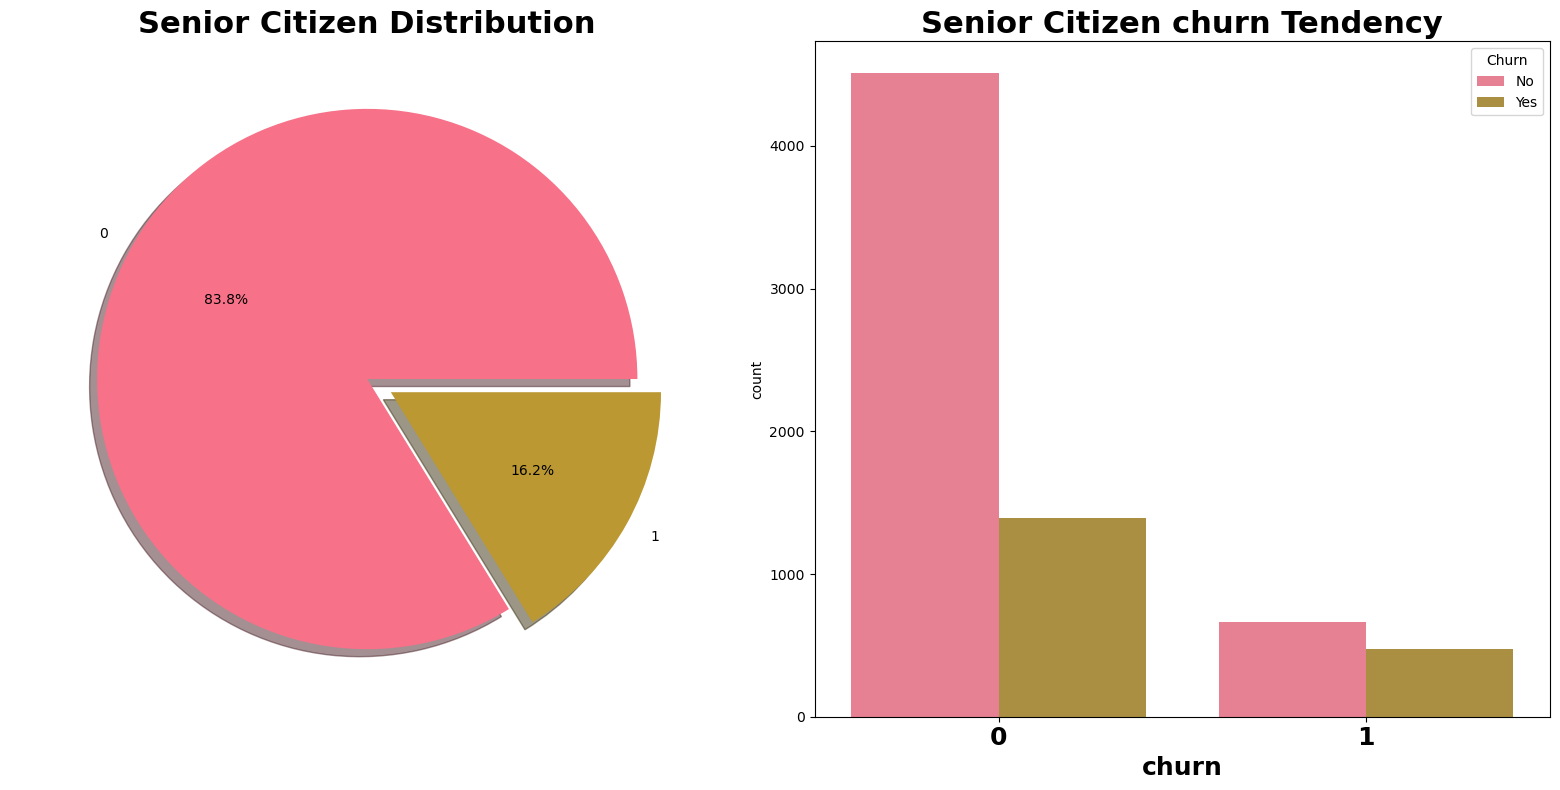

In [14]:
sns.set_palette("husl")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["SeniorCitizen"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("Senior Citizen Distribution",fontsize=22,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="SeniorCitizen",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Senior Citizen churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

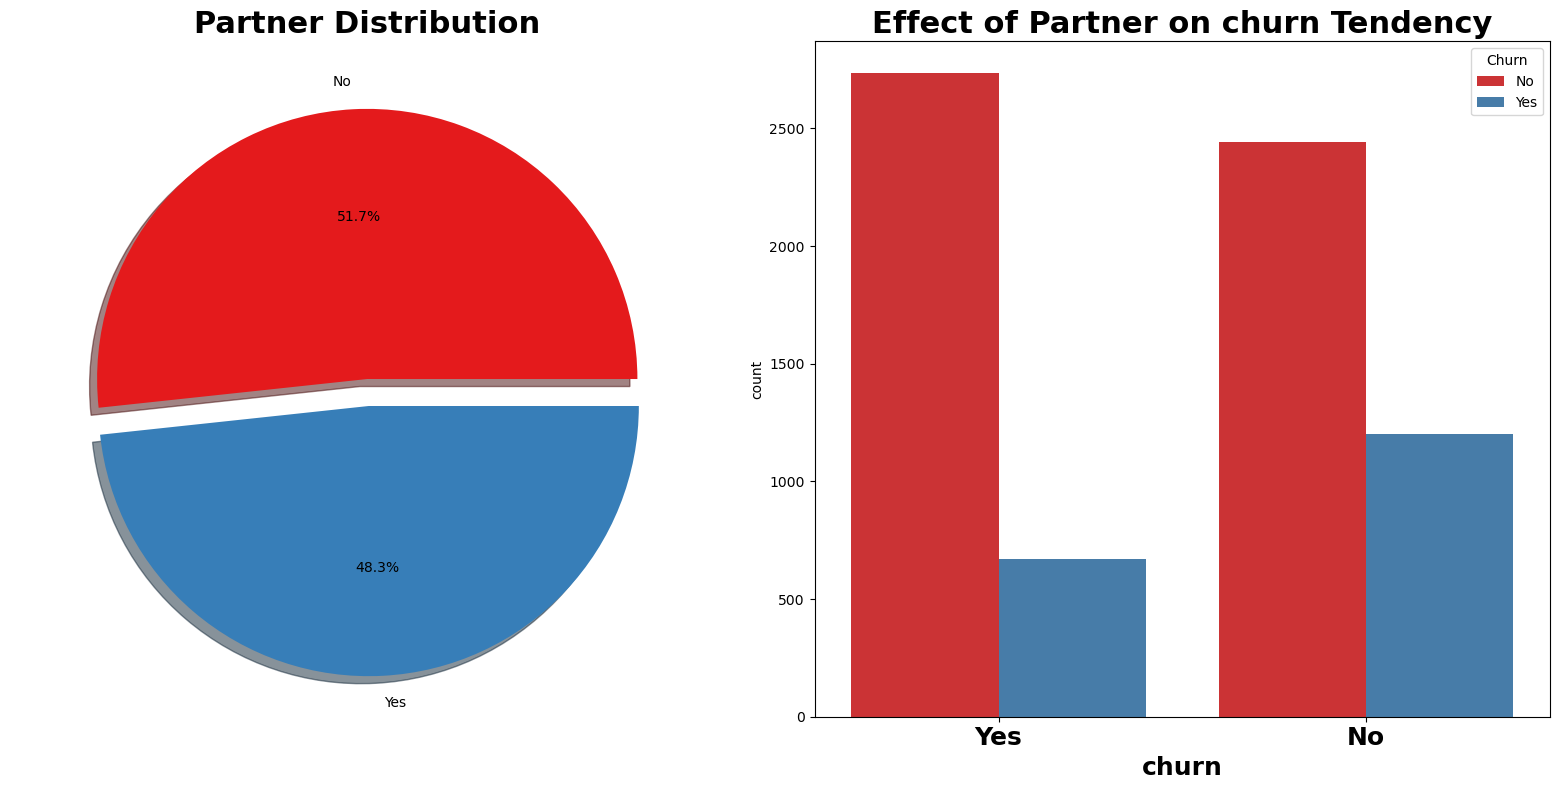

In [15]:
plt.rcParams["figure.autolayout"]=True
sns.set_palette("Set1")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["Partner"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("Partner Distribution",fontsize=22,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="Partner",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Effect of Partner on churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

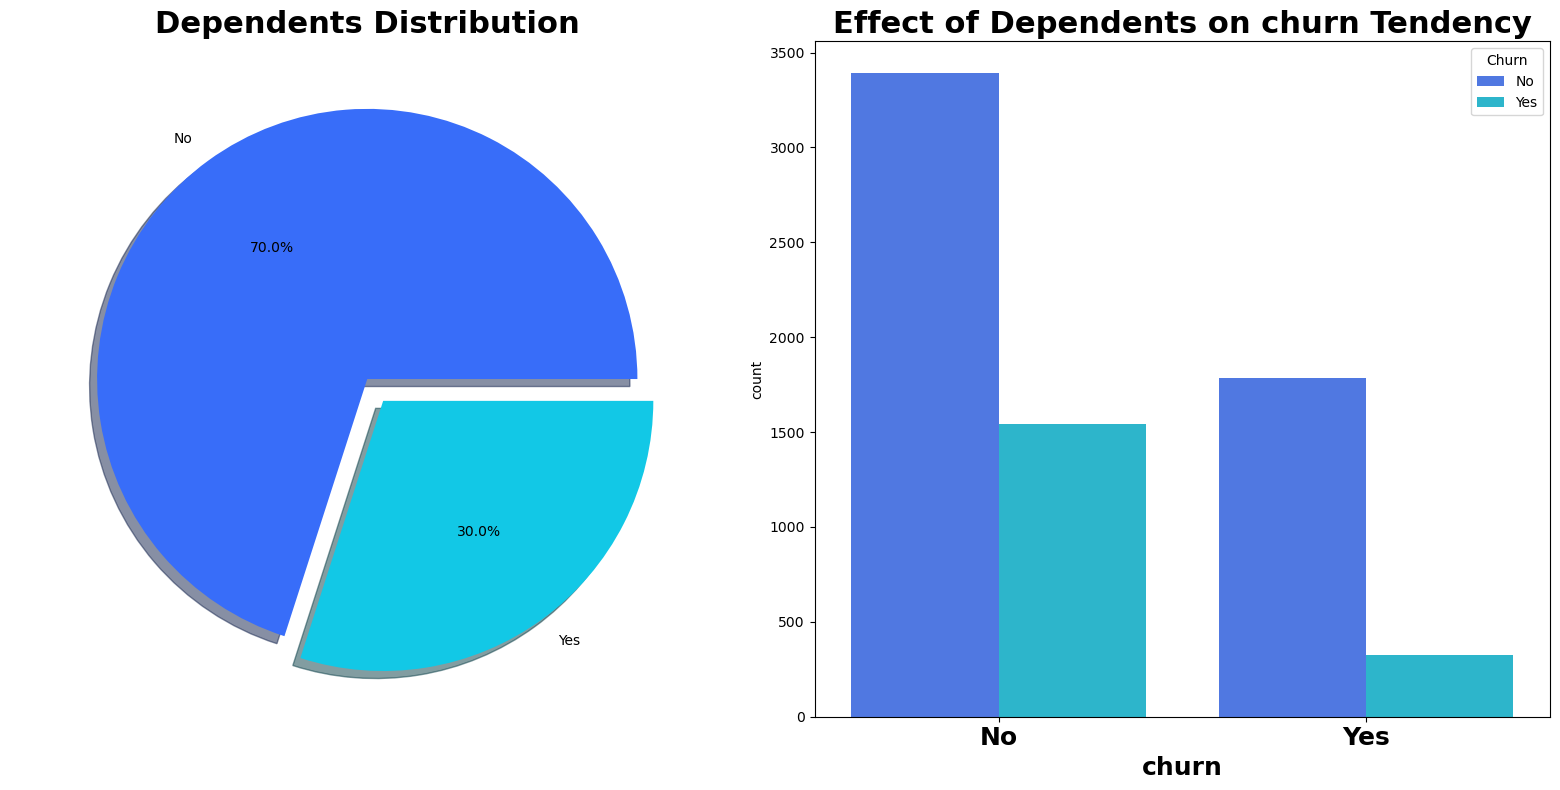

In [16]:
sns.set_palette("rainbow")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["Dependents"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("Dependents Distribution",fontsize=22,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="Dependents",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Effect of Dependents on churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

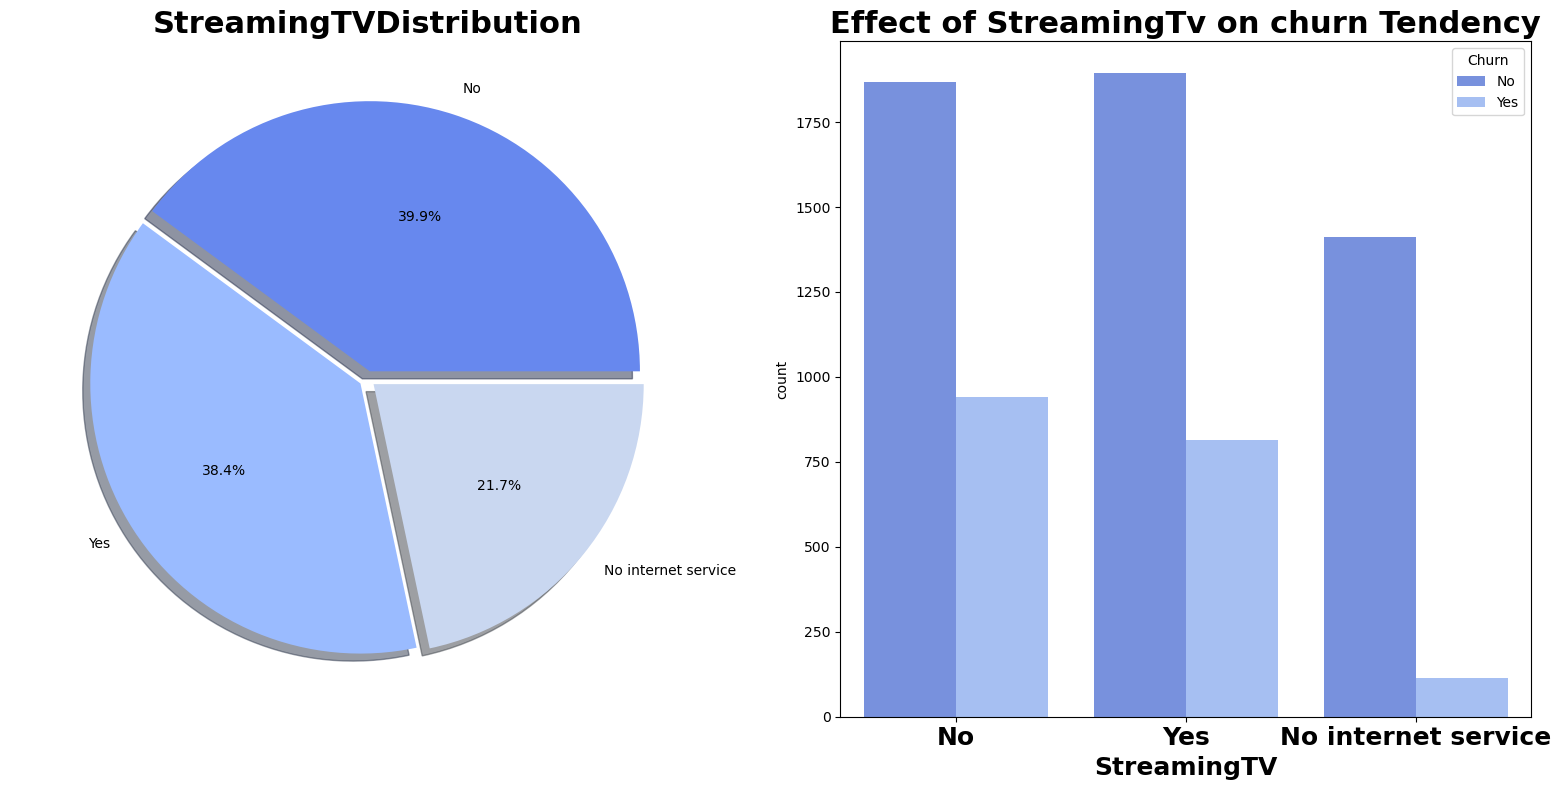

In [17]:
sns.set_palette("coolwarm")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["StreamingTV"].value_counts().plot.pie(explode=[0.03,0.03,0.03],autopct="%3.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("StreamingTVDistribution",fontsize=22,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="StreamingTV",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Effect of StreamingTv on churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("StreamingTV",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

KeyError: 'InternateService'

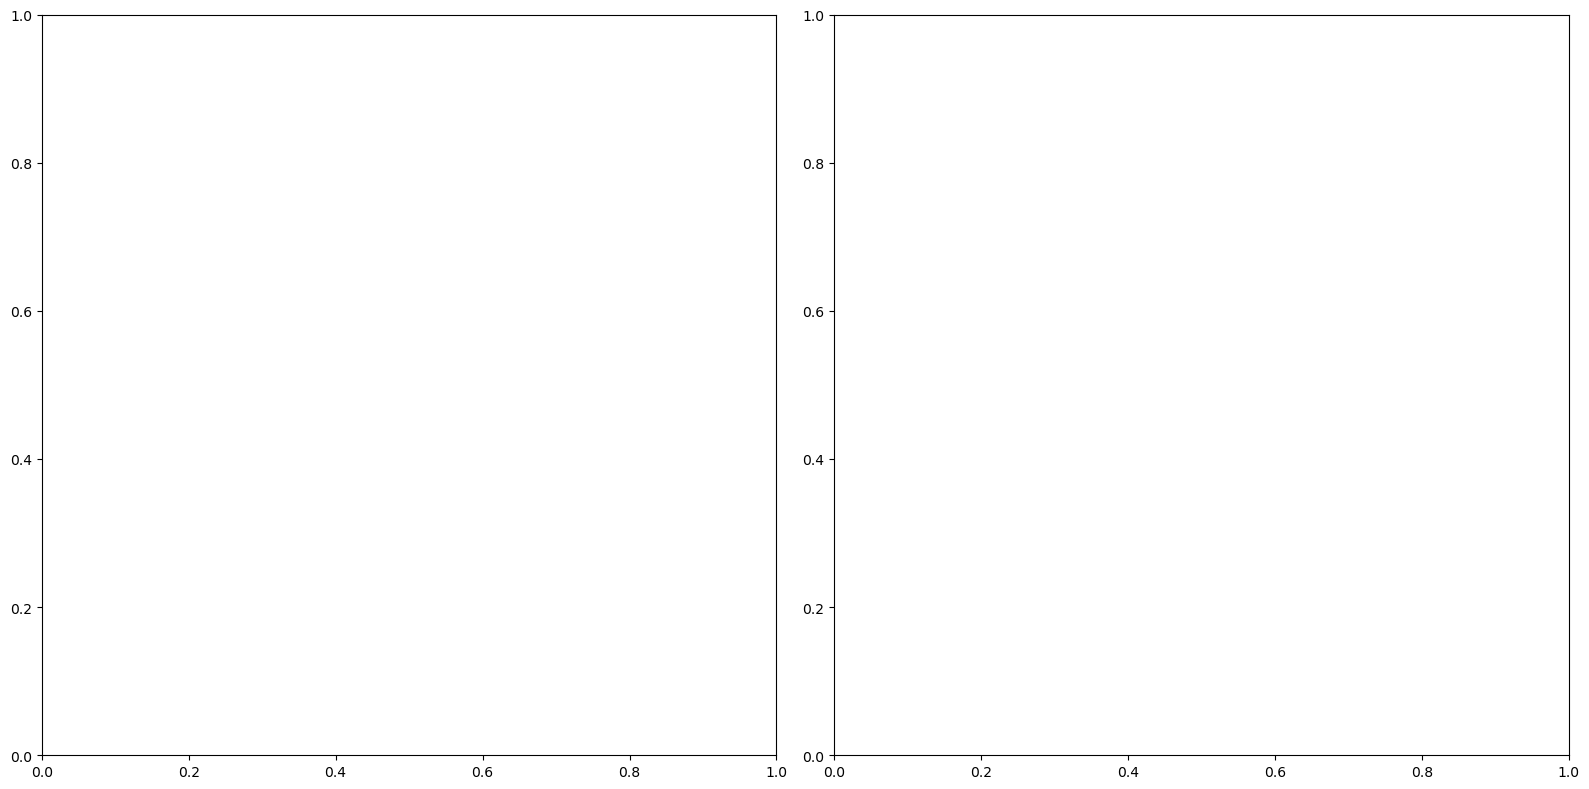

In [40]:
sns.set_palette("tab10")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["InternateService"].value_counts().plot.pie(explode=[0.03,0.03,0.03],autopct="%3.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("InternateService Ditribution",fontsize=20,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="InternateService",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Effect of StreamingTv on churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("InternetService",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

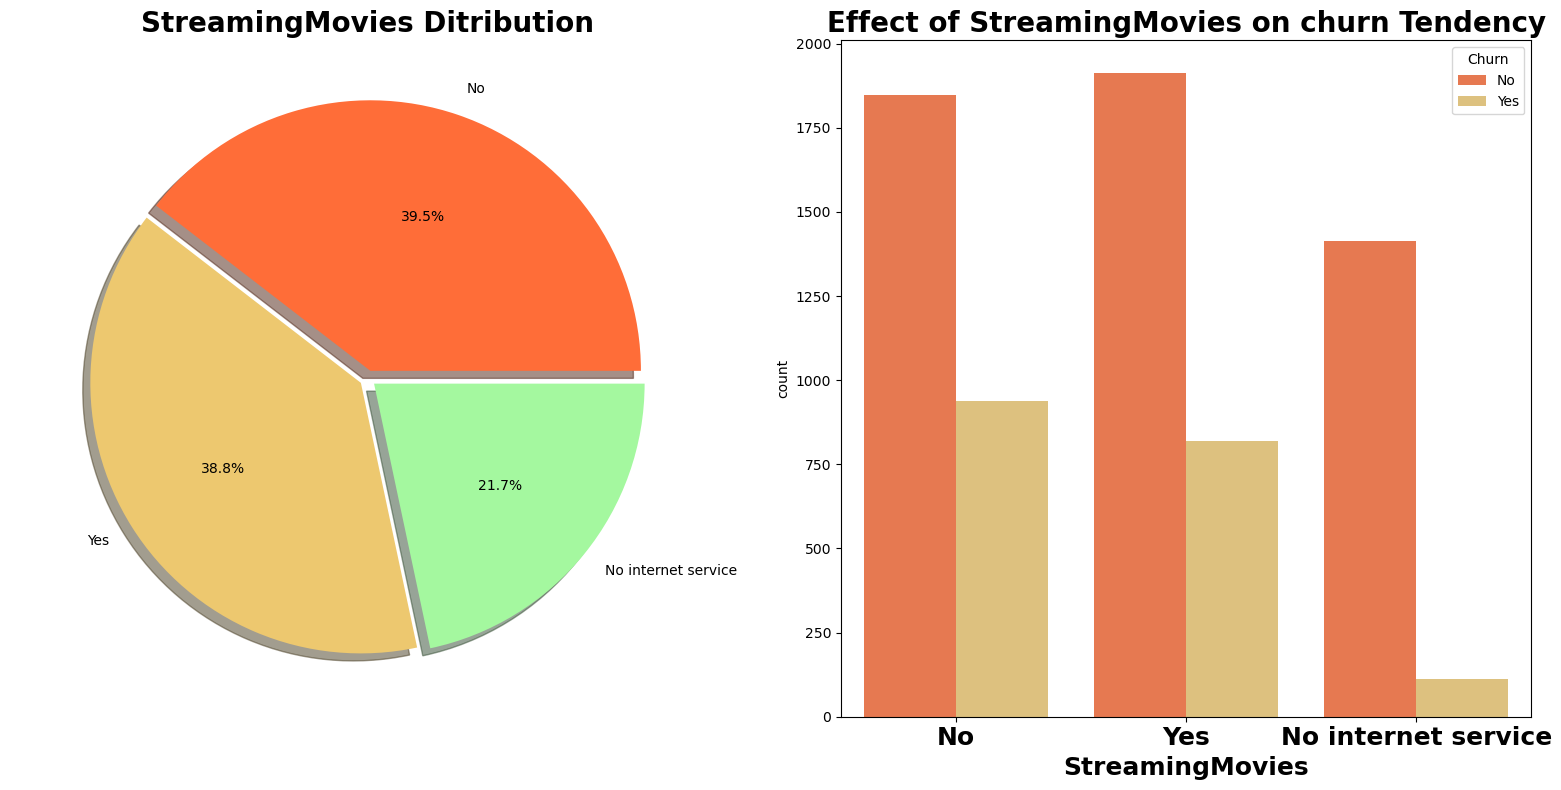

In [36]:
sns.set_palette("rainbow_r")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["StreamingMovies"].value_counts().plot.pie(explode=[0.03,0.03,0.03],autopct="%3.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("StreamingMovies Ditribution",fontsize=20,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="StreamingMovies",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Effect of StreamingMovies on churn Tendency",fontsize=20,fontweight="bold")
ax[1].set_xlabel("StreamingMovies",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

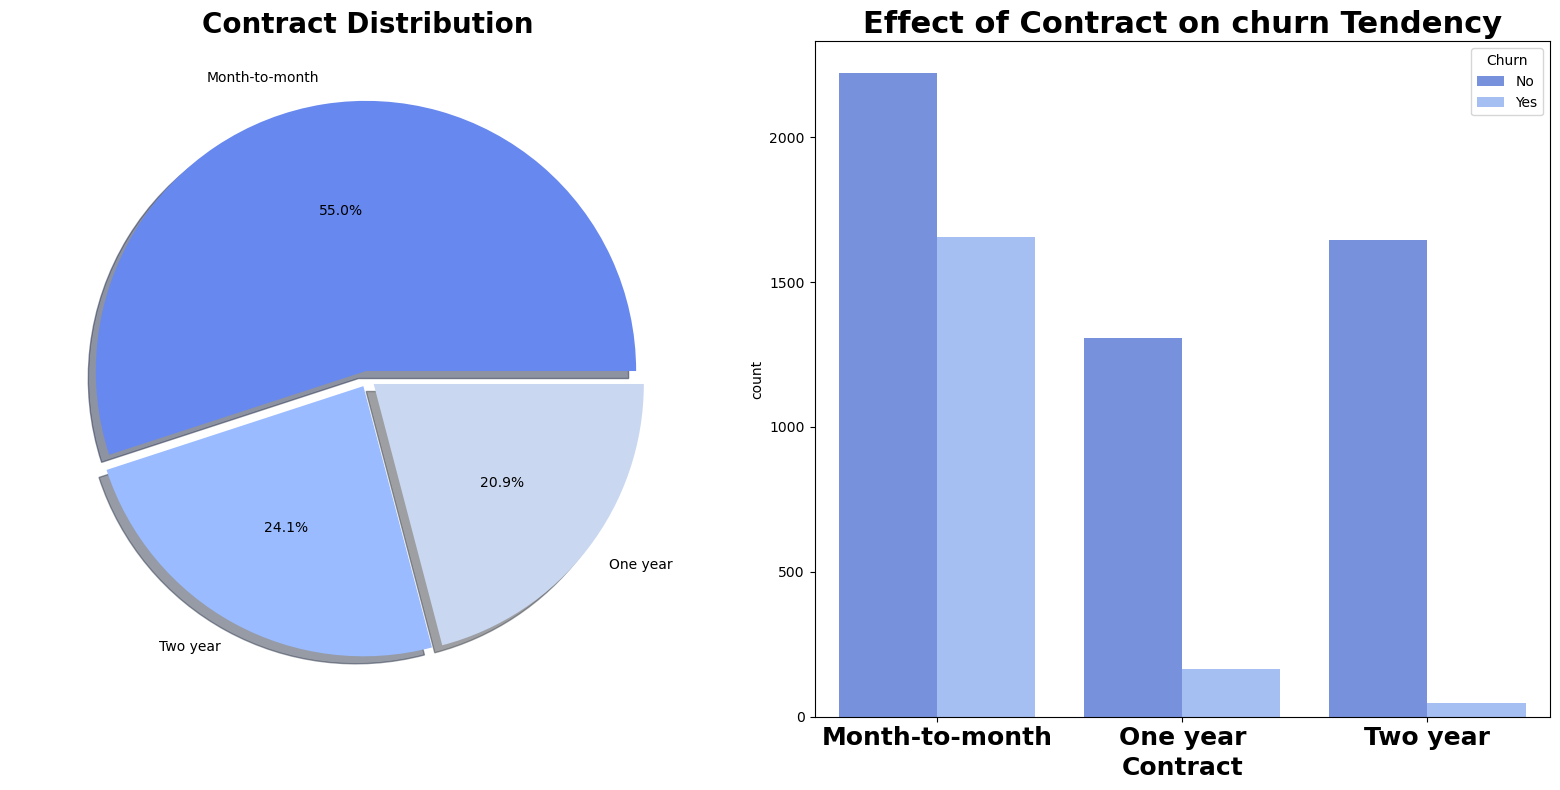

In [38]:
sns.set_palette("coolwarm")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["Contract"].value_counts().plot.pie(explode=[0.03,0.03,0.03],autopct="%2.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("Contract Distribution",fontsize=20,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="Contract",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Effect of Contract on churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("Contract",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

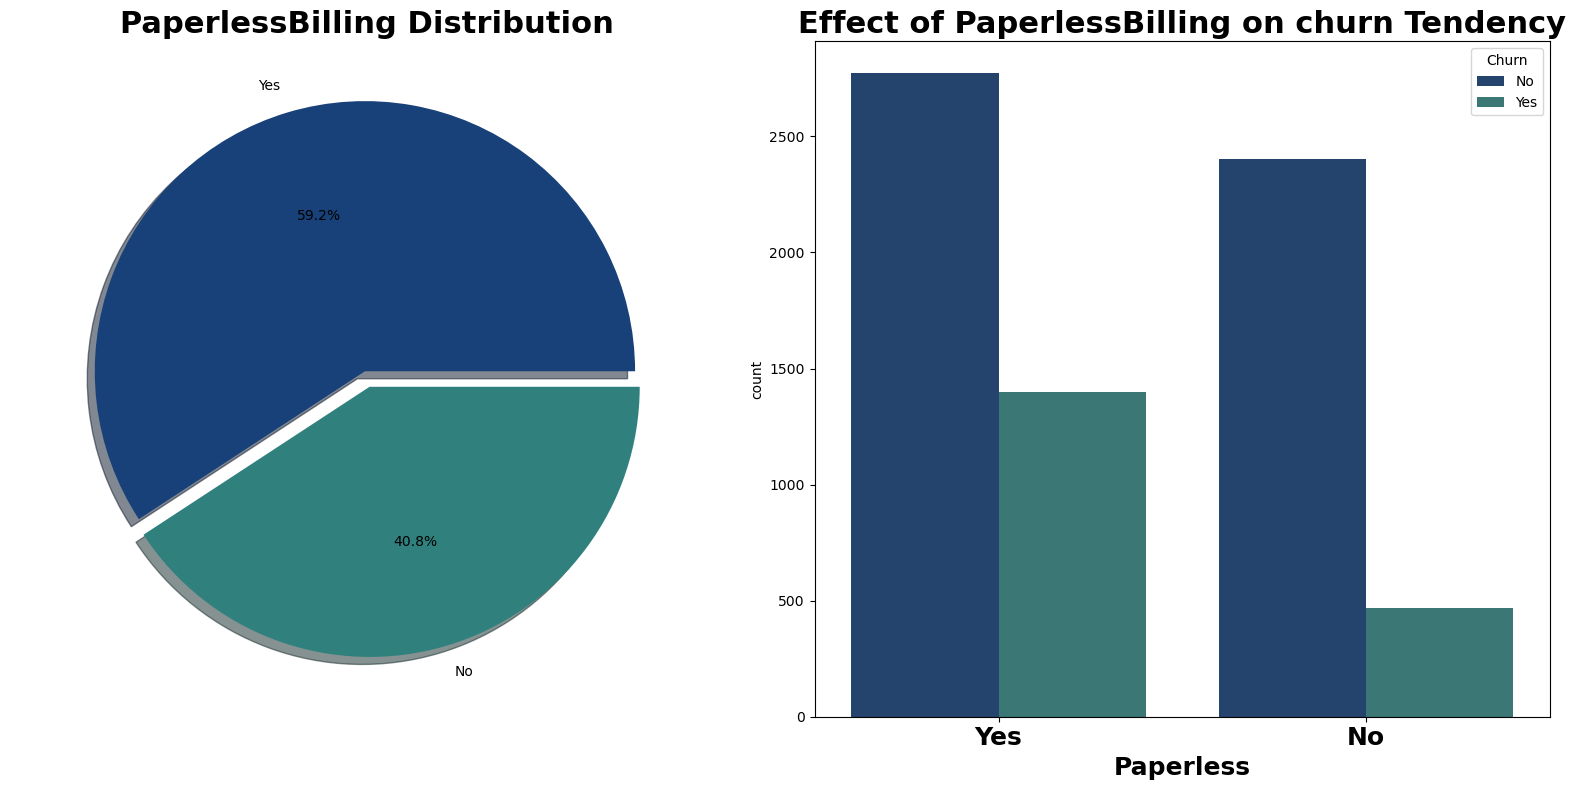

In [42]:
sns.set_palette("gist_earth")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["PaperlessBilling"].value_counts().plot.pie(explode=[0.03,0.03,],autopct="%2.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("PaperlessBilling Distribution",fontsize=22,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="PaperlessBilling",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Effect of PaperlessBilling on churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("Paperless",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

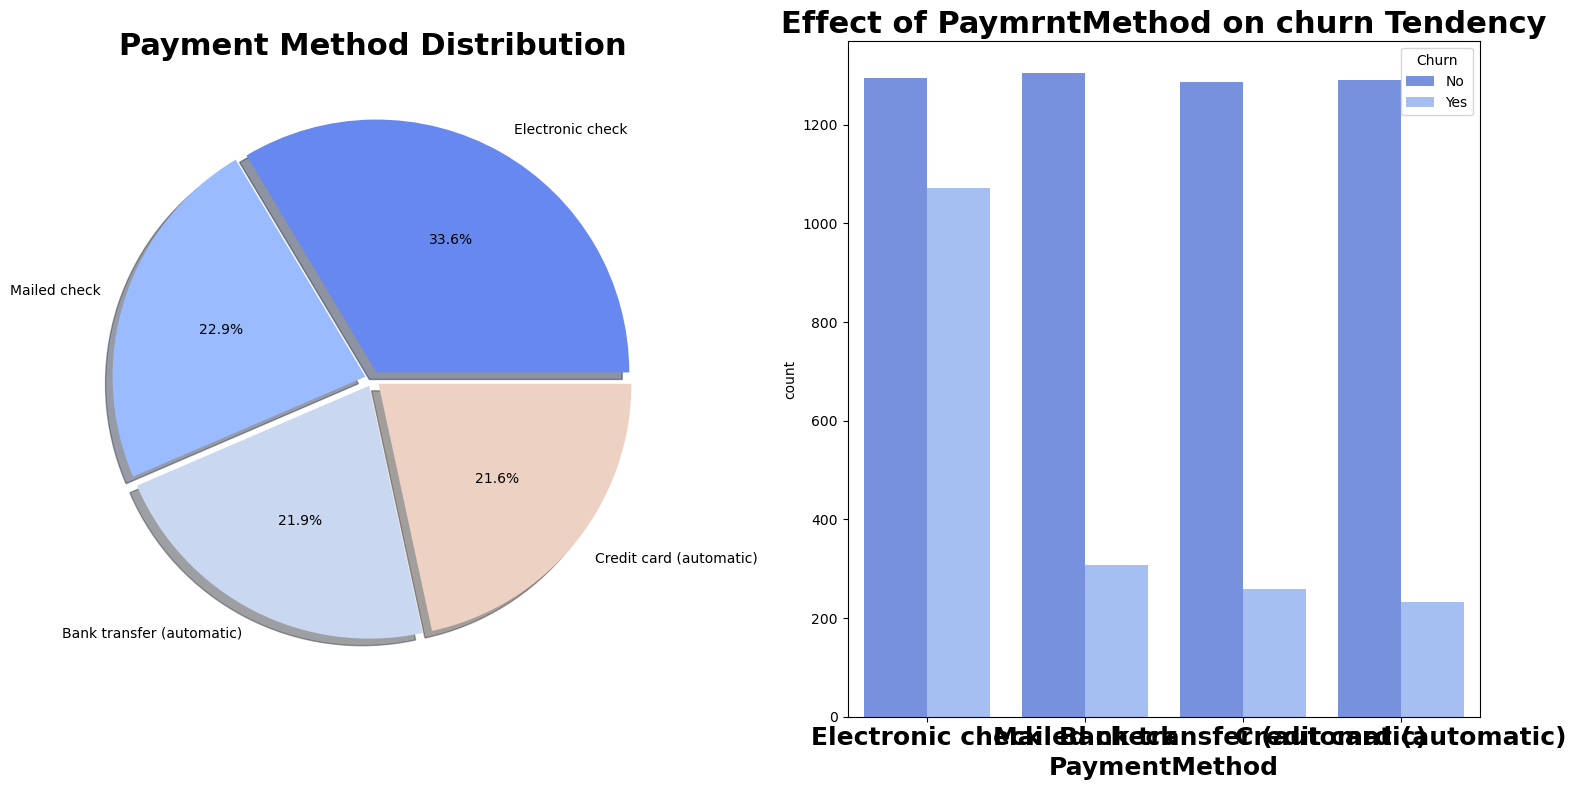

In [44]:
sns.set_palette("coolwarm")
f,ax=plt.subplots(1,2,figsize=(16,8))
df["PaymentMethod"].value_counts().plot.pie(explode=[0.03,0.03,0.03,0.03],autopct="%2.1f%%",ax=ax[0],shadow=True)
ax[0].set_title("Payment Method Distribution",fontsize=22,fontweight="bold")
ax[0].set_ylabel(" ")
sns.countplot(x="PaymentMethod",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Effect of PaymrntMethod on churn Tendency",fontsize=22,fontweight="bold")
ax[1].set_xlabel("PaymentMethod",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\Ankita Singh\AppData\Local\Temp\ipykernel_16252\1872231591.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Ankita Singh\AppData\Local\Temp\ipykernel_16252\1872231591.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Ankita Singh\AppData\Local\Te

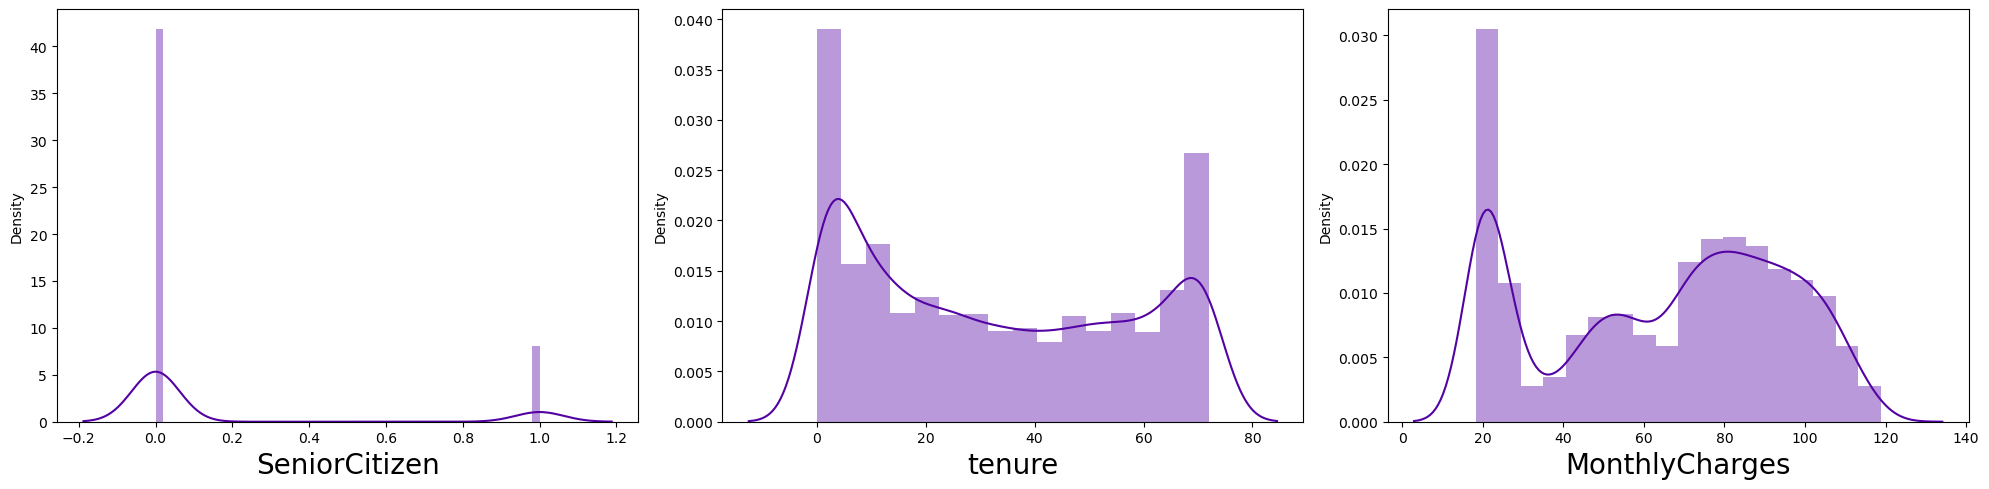

In [50]:
num=['tenure','MonthlyCharges','TotalCharges']

C:\Users\Ankita Singh\AppData\Local\Temp\ipykernel_16252\717311621.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Ankita Singh\AppData\Local\Temp\ipykernel_16252\717311621.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Ankita Singh\AppData\Local\Temp

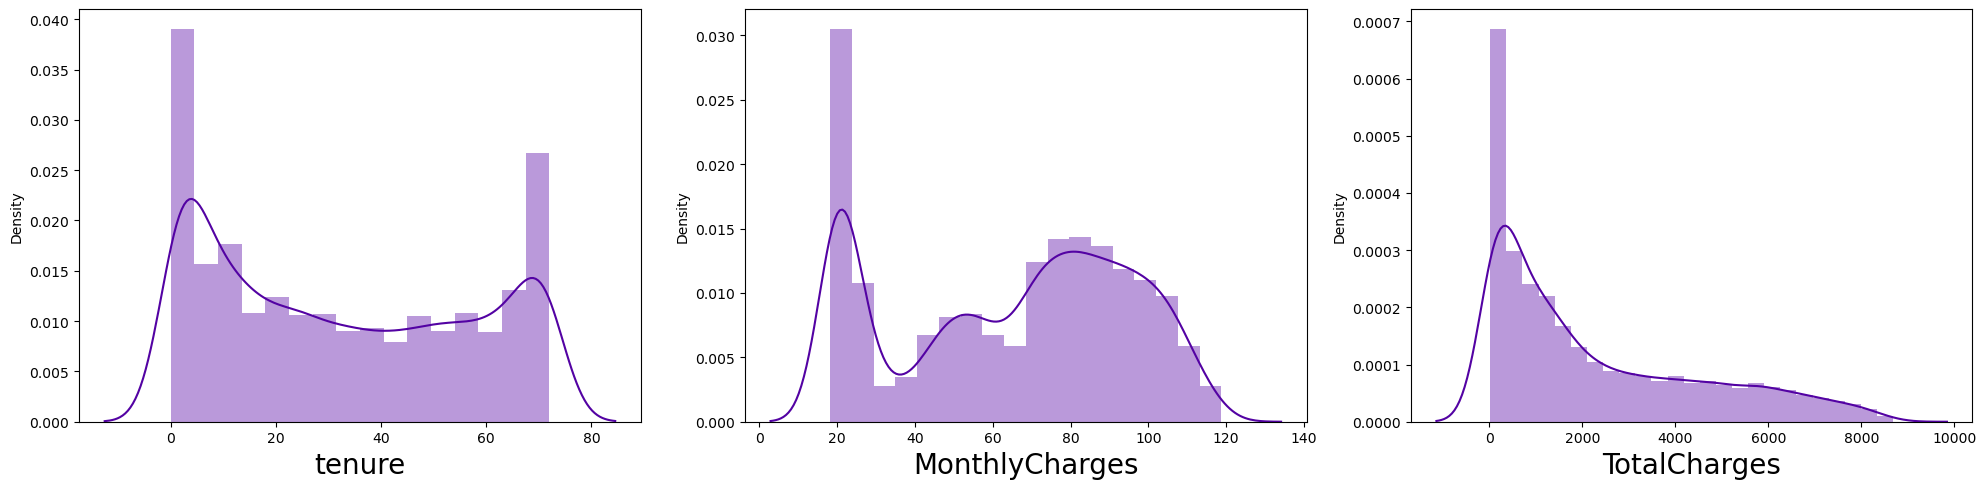

In [52]:

plt.figure(figsize=(20,5),facecolor='white')
sns.set_palette("plasma")
plotnum=1
for col in num:
    if plotnum<=3:
        plt.subplot(1,3,plotnum)
        sns.distplot(df[col])
        plt.xlabel(col,fontsize=20)
    plotnum+=1
plt.show()

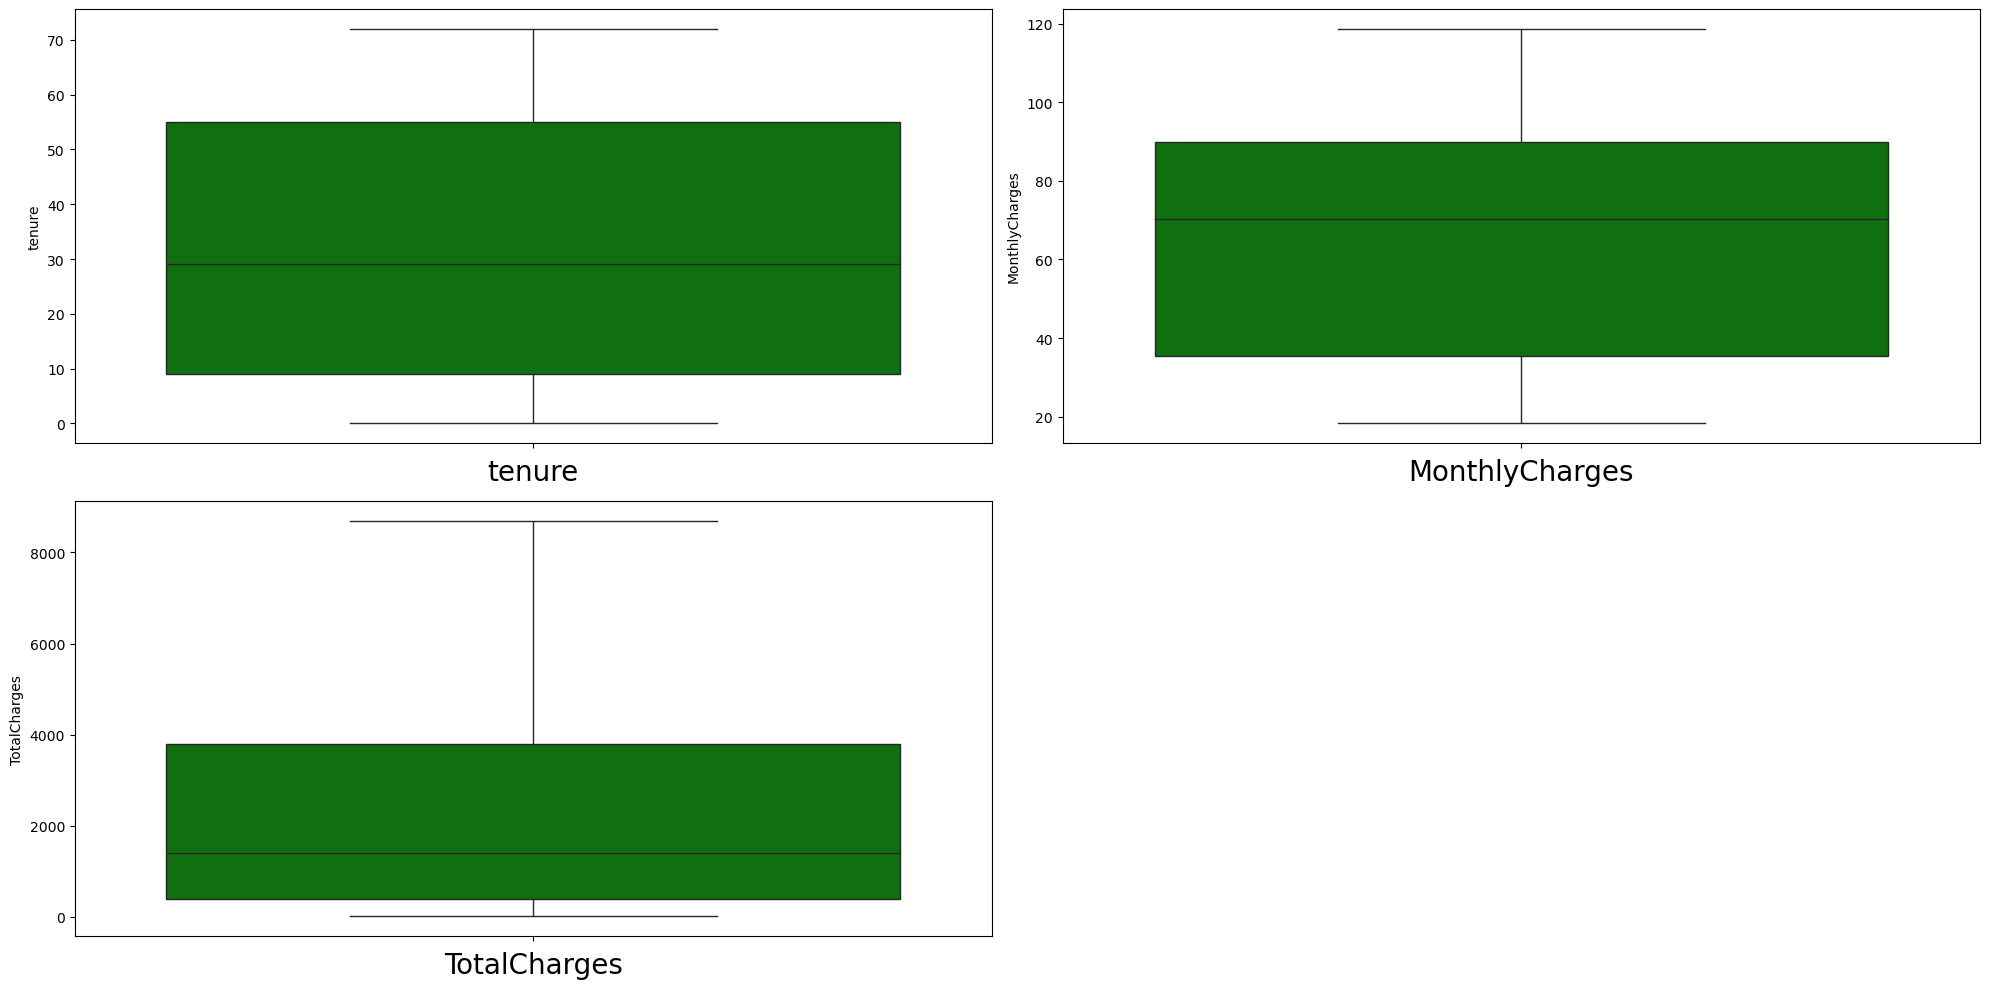

In [60]:
plt.figure(figsize=(20,10),facecolor='white')
#sns.set_palette("plasma")
plotnumber=1
for column in num:
    if plotnumber<=3:
        x=plt.subplot(2,2,plotnumber)
        sns.boxplot(df[column],color='g')
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()